YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  5 of 5 completed
/var/folders/7p/8k48kgls7nq0f99vjgs9qkrm0000gn/T/ipykernel_29970/2636010678.py:41: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  close_prices.fillna(method='ffill', inplace=True)


Data download complete.

Missing values before forward fill:
Ticker
BTC-USD     0
ETH-USD     0
LTC-USD     0
USDT-USD    0
XRP-USD     0
dtype: int64

Missing values after forward fill (should ideally be 0, except maybe at start):
Ticker
BTC-USD     0
ETH-USD     0
LTC-USD     0
USDT-USD    0
XRP-USD     0
dtype: int64

Working with 2611 data points after cleaning.

--- Descriptive Statistics (Closing Prices) ---
           count          mean           std          min          25%  \
Ticker                                                                   
BTC-USD   2611.0  27790.287994  22068.691596  3236.761719  8929.159180   
ETH-USD   2611.0   1492.192564   1226.867725    84.308296   268.861679   
LTC-USD   2611.0     95.360793     55.307003    23.464331    58.764734   
USDT-USD  2611.0      1.001168      0.004902     0.966644     0.999900   
XRP-USD   2611.0      0.553388      0.376422     0.139635     0.316894   

                   50%           75%            max  
Ticker   

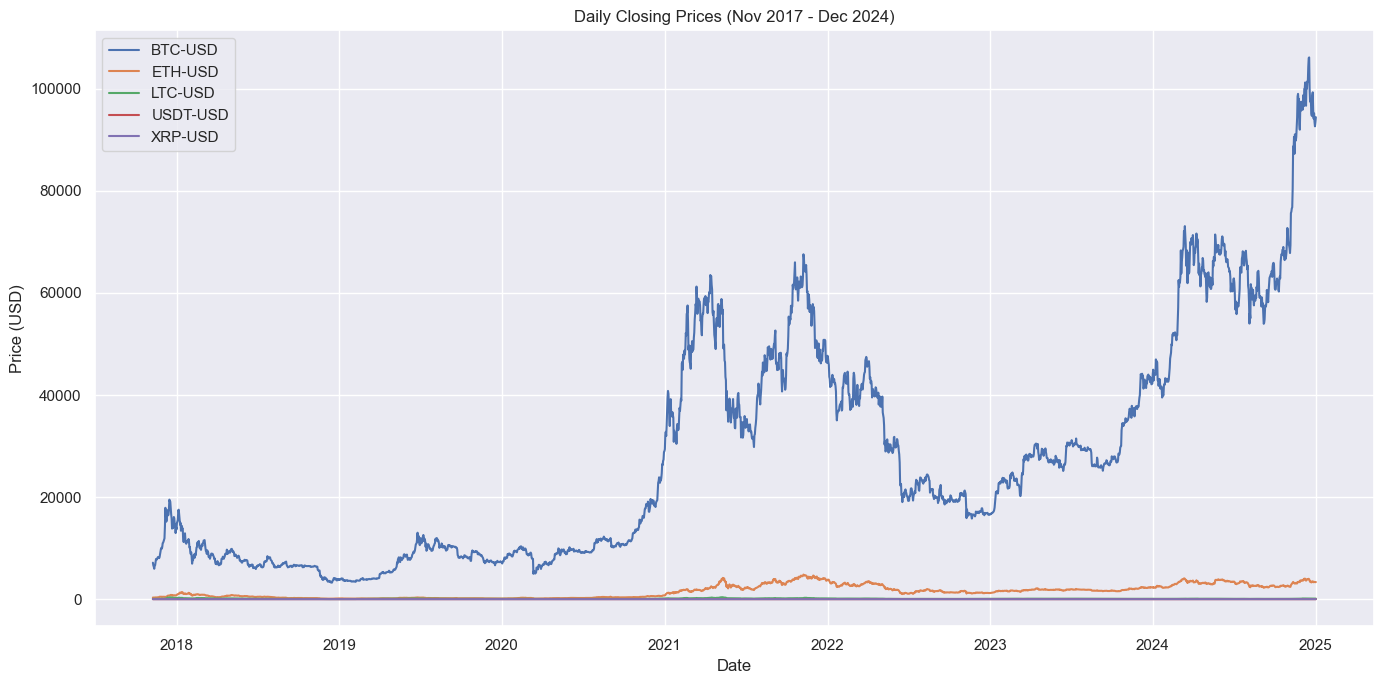

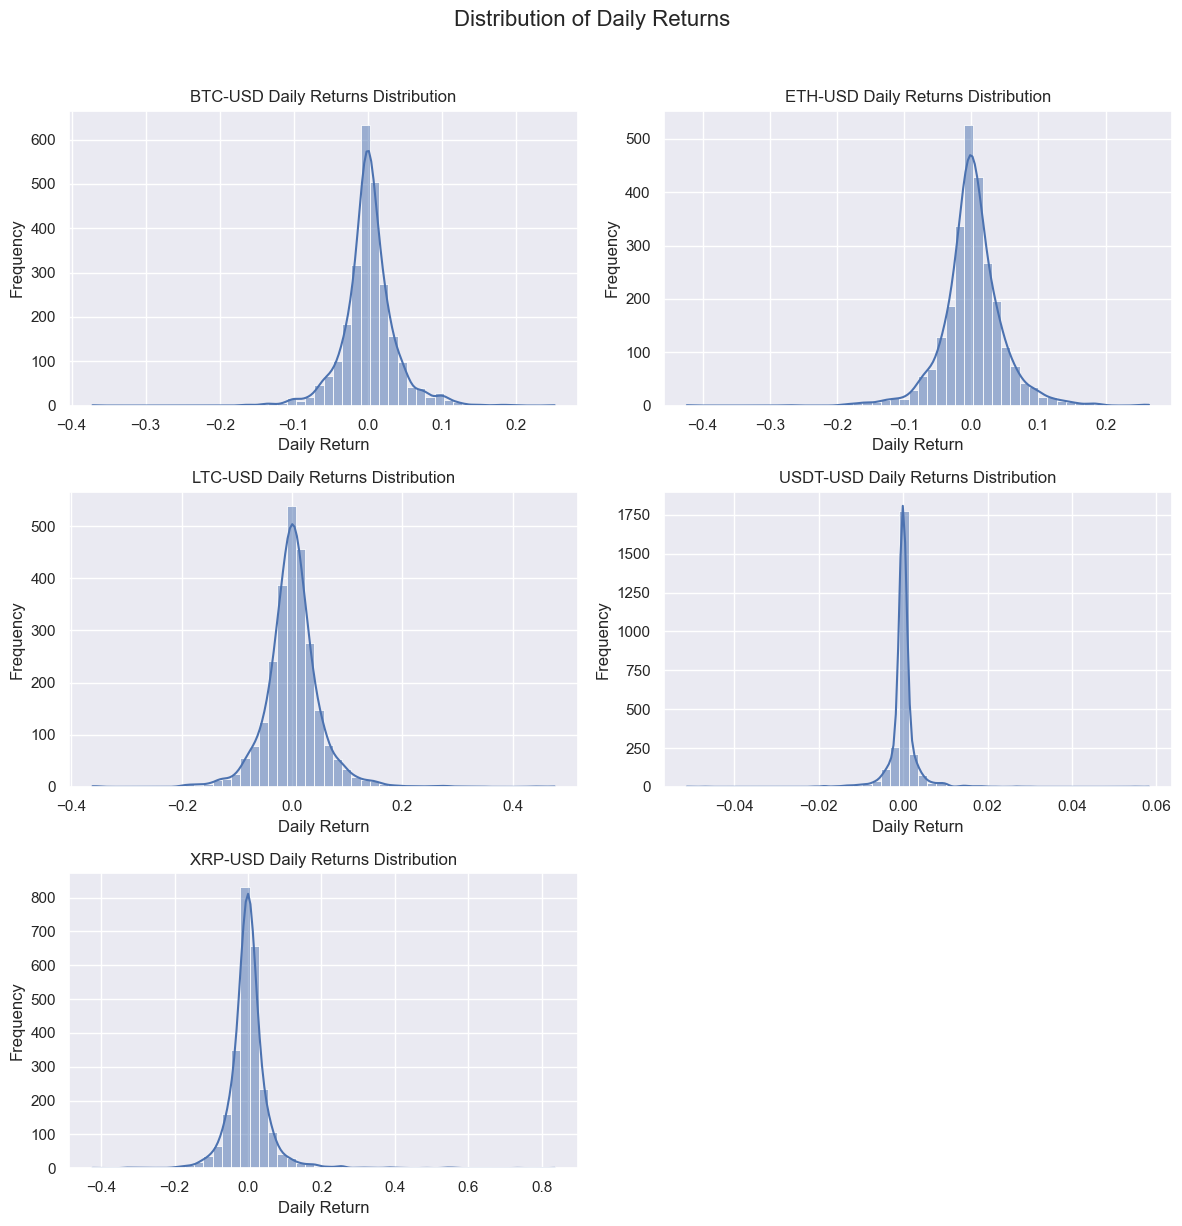

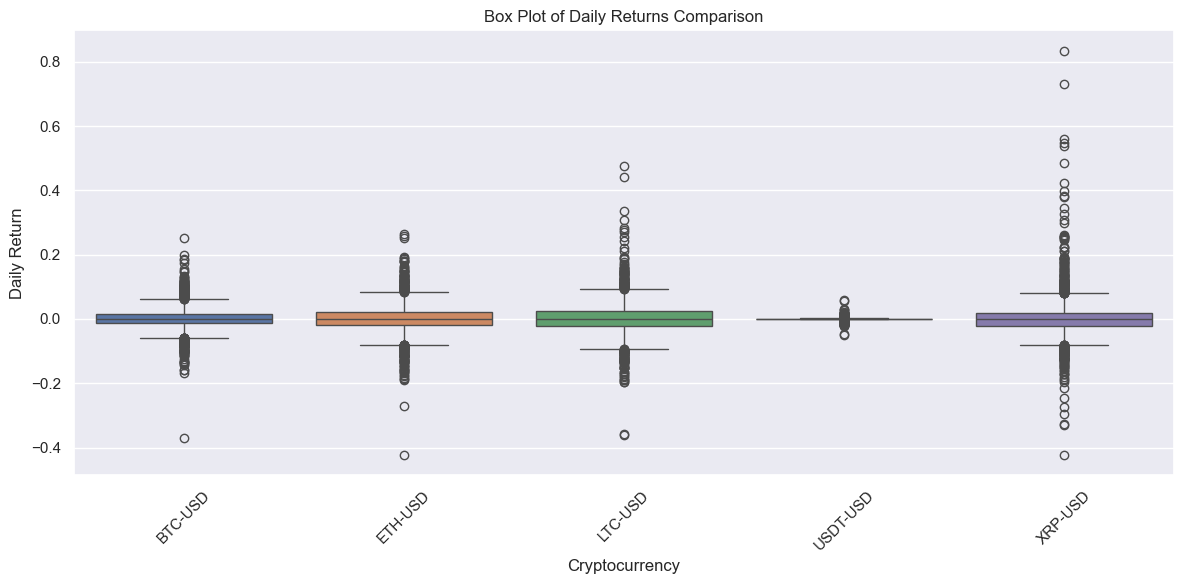

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Required for isnan check if using older pandas

# --- Configuration ---
tickers = ['BTC-USD', 'ETH-USD', 'USDT-USD', 'XRP-USD', 'LTC-USD']
start_date = '2017-11-09'
end_date = '2025-01-02' # yfinance downloads up to, but not including, the end date

# --- Data Acquisition ---
print(f"Downloading data for {tickers} from {start_date} to {end_date}...")
try:
    # Download OHLCV data
    raw_data = yf.download(tickers, start=start_date, end=end_date)
    if raw_data.empty:
        print("No data downloaded. Check tickers and date range.")
        exit()
    print("Data download complete.")

    # Select Closing Prices - Handle potential MultiIndex
    if isinstance(raw_data.columns, pd.MultiIndex):
        close_prices = raw_data['Close']
    else:
        # If only one ticker was downloaded successfully, it might not be MultiIndex
        close_prices = raw_data[['Close']].rename(columns={'Close': tickers[0]}) # Adjust if needed

    # Handle potential all-NaN columns if some tickers failed download completely within the range
    close_prices = close_prices.dropna(axis=1, how='all')
    if close_prices.empty:
        print("No closing price data available for any ticker after handling.")
        exit()

    # --- Data Cleaning: Handle Missing Values ---
    # Check for missing values before filling
    print("\nMissing values before forward fill:")
    print(close_prices.isnull().sum())

    # Forward fill missing values - reasonable for daily financial data
    close_prices.fillna(method='ffill', inplace=True)

    # Check again - some NaNs might remain at the beginning if data starts later
    print("\nMissing values after forward fill (should ideally be 0, except maybe at start):")
    print(close_prices.isnull().sum())

    # Optional: Drop any remaining rows with NaNs (usually at the start if ffill wasn't enough)
    close_prices.dropna(inplace=True)

    print(f"\nWorking with {len(close_prices)} data points after cleaning.")
    print("\n--- Descriptive Statistics (Closing Prices) ---")
    # Calculate and print descriptive statistics for closing prices
    # Using .T to transpose for better readability if many tickers
    print(close_prices.describe().T)

    # --- Calculate Daily Returns ---
    # Use percentage change for daily returns
    daily_returns = close_prices.pct_change().dropna()

    print("\n--- Descriptive Statistics (Daily Returns) ---")
    # Calculate and print descriptive statistics for daily returns
    print(daily_returns.describe().T)

    # --- Data Visualization ---
    print("\nGenerating plots...")

    # Set plot style
    sns.set(style="darkgrid")

    # 1. Time Series Plot of Closing Prices
    plt.figure(figsize=(14, 7))
    for ticker in close_prices.columns:
         # Check if the column exists before plotting (robustness for failed downloads)
        if ticker in close_prices:
            plt.plot(close_prices.index, close_prices[ticker], label=ticker)
    plt.title('Daily Closing Prices (Nov 2017 - Dec 2024)')
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 2. Individual Time Series Plots (Optional but good for clarity)
    # fig, axes = plt.subplots(nrows=len(close_prices.columns), ncols=1, figsize=(12, 3 * len(close_prices.columns)), sharex=True)
    # if len(close_prices.columns) == 1: # Handle case of single ticker
    #     axes = [axes]
    # for i, ticker in enumerate(close_prices.columns):
    #      if ticker in close_prices:
    #         axes[i].plot(close_prices.index, close_prices[ticker], label=ticker)
    #         axes[i].set_title(f'{ticker} Daily Closing Price')
    #         axes[i].set_ylabel('Price (USD)')
    # plt.xlabel('Date')
    # plt.tight_layout()
    # plt.show()


    # 3. Histograms of Daily Returns (using Seaborn for better aesthetics)
    # Calculate number of rows/cols for subplots
    n_cols = 2
    n_rows = (len(daily_returns.columns) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
    axes = axes.flatten() # Flatten to easily iterate

    for i, ticker in enumerate(daily_returns.columns):
        if ticker in daily_returns:
            sns.histplot(daily_returns[ticker], kde=True, ax=axes[i], bins=50)
            axes[i].set_title(f'{ticker} Daily Returns Distribution')
            axes[i].set_xlabel('Daily Return')
            axes[i].set_ylabel('Frequency')

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle('Distribution of Daily Returns', y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()


    # 4. Box Plots of Daily Returns
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=daily_returns)
    plt.title('Box Plot of Daily Returns Comparison')
    plt.xlabel('Cryptocurrency')
    plt.ylabel('Daily Return')
    plt.xticks(rotation=45) # Rotate labels if needed
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"An error occurred: {e}")